# Clustering

In [4]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

In [14]:
skincare = pd.read_csv("dataset/skincare_final.csv", index_col = 0)

In [15]:
skincare.head()

,product_name,brand_name,loves_count,rating,reviews,price_usd,secondary_category,tertiary_category,size (oz),count_cleansers,...,count_water_based,has_cleansers,has_moisturizers,has_exfoliants,has_actives,has_soothing,has_preservatives,has_fragrance,has_oils,has_water_based
15,GENIUS Ultimate Anti-Aging Melting Cleanser,Algenist,9314,4.0569,334.0,38.0,Cleansers,Face Wash & Cleansers,5.00,0,...,1,0,1,0,0,0,1,1,1,1
16,Gentle Rejuvenating Cleanser,Algenist,7681,4.2689,264.0,28.0,Cleansers,Face Wash & Cleansers,4.00,3,...,2,1,1,1,0,0,1,1,0,1
17,Advanced Anti-Aging Repairing Oil,Algenist,10676,4.4531,245.0,82.0,Moisturizers,Face Oils,1.00,0,...,0,0,1,0,1,0,0,0,1,0
18,ALIVE Prebiotic Balancing Mask,Algenist,14367,4.3729,118.0,38.0,Masks,Face Masks,1.70,5,...,2,1,1,1,1,0,1,1,0,1
19,Balancing Cleanser,Alpha-H,3612,4.5455,77.0,38.0,Cleansers,Face Wash & Cleansers,6.25,1,...,1,1,1,1,0,1,1,1,0,1


In [16]:
skincare.isna().mean()

product_name           0.000000
brand_name             0.000000
loves_count            0.000000
rating                 0.000000
reviews                0.000000
price_usd              0.000000
secondary_category     0.000000
tertiary_category      0.000000
size (oz)              0.156134
count_cleansers        0.000000
count_moisturizers     0.000000
count_exfoliants       0.000000
count_actives          0.000000
count_soothing         0.000000
count_preservatives    0.000000
count_fragrance        0.000000
count_oils             0.000000
count_water_based      0.000000
has_cleansers          0.000000
has_moisturizers       0.000000
has_exfoliants         0.000000
has_actives            0.000000
has_soothing           0.000000
has_preservatives      0.000000
has_fragrance          0.000000
has_oils               0.000000
has_water_based        0.000000
dtype: float64

In [ ]:
# df = df[~(df['is_recommended'].isna())]

In [ ]:
# df.isna().mean()

In [17]:
skincare.columns

Index(['product_name', 'brand_name', 'loves_count', 'rating', 'reviews',
       'price_usd', 'secondary_category', 'tertiary_category', 'size (oz)',
       'count_cleansers', 'count_moisturizers', 'count_exfoliants',
       'count_actives', 'count_soothing', 'count_preservatives',
       'count_fragrance', 'count_oils', 'count_water_based', 'has_cleansers',
       'has_moisturizers', 'has_exfoliants', 'has_actives', 'has_soothing',
       'has_preservatives', 'has_fragrance', 'has_oils', 'has_water_based'],
      dtype='object')

In [18]:
# separating ml features from metadata 

# selecting only formulation features
formulation_features = [
    'count_cleansers', 'count_moisturizers', 'count_exfoliants',
    'count_actives', 'count_soothing', 'count_preservatives',
    'count_fragrance', 'count_oils', 'count_water_based',
    'has_cleansers', 'has_moisturizers', 'has_exfoliants', 
    'has_actives', 'has_soothing', 'has_preservatives',
    'has_fragrance', 'has_oils', 'has_water_based'
]

# create feature matrix
X = skincare[formulation_features]

# scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

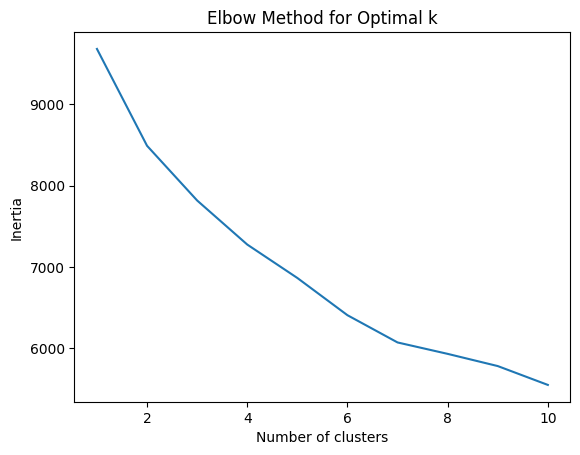

In [19]:
from sklearn.cluster import KMeans

# Determine optimal number of clusters (optional)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(1, 11), inertia)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [20]:
# Apply clustering with chosen k
kmeans = KMeans(n_clusters=4, random_state=42)
skincare['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
cluster_profile = skincare.groupby('cluster')[formulation_features].mean()
print(cluster_profile)

         count_cleansers  count_moisturizers  count_exfoliants  count_actives  \
cluster                                                                         
0               0.280822            2.246575          1.013699       1.013699   
1               2.378378            2.540541          2.247748       0.914414   
2               1.316667            1.641667          1.750000       0.666667   
3               0.420000            0.280000          0.580000       0.420000   

         count_soothing  count_preservatives  count_fragrance  count_oils  \
cluster                                                                     
0              0.719178             2.075342         2.095890    2.794521   
1              0.698198             2.058559         1.932432    2.418919   
2              0.925000             1.541667         0.000000    2.025000   
3              0.160000             0.420000         0.540000    2.280000   

         count_water_based  has_cleansers  has_moi

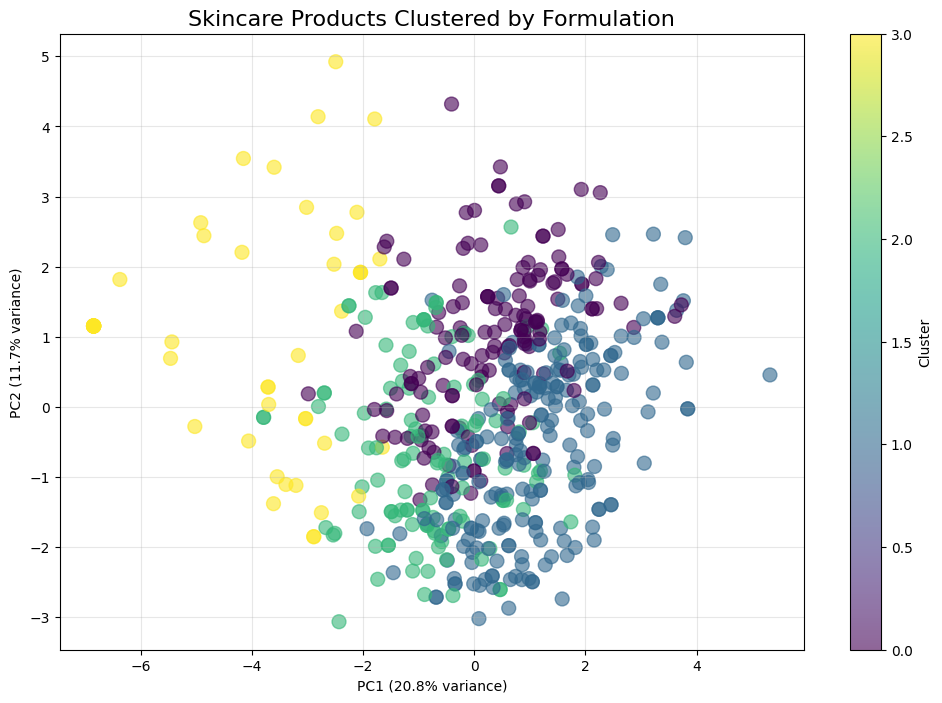

In [21]:
from sklearn.decomposition import PCA

clusters = kmeans.fit_predict(X_scaled)

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': clusters
})

# Add product names for labeling (optional)
plot_df['product'] = skincare['product_name']

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(plot_df['PC1'], plot_df['PC2'], 
                     c=plot_df['Cluster'], cmap='viridis', 
                     alpha=0.6, s=100)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Skincare Products Clustered by Formulation', fontsize=16)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
results = skincare[['product_name', 'brand_name', 'cluster'] + formulation_features]

In [23]:
results.head()

,product_name,brand_name,cluster,count_cleansers,count_moisturizers,count_exfoliants,count_actives,count_soothing,count_preservatives,count_fragrance,...,count_water_based,has_cleansers,has_moisturizers,has_exfoliants,has_actives,has_soothing,has_preservatives,has_fragrance,has_oils,has_water_based
15,GENIUS Ultimate Anti-Aging Melting Cleanser,Algenist,0,0,1,0,0,0,3,2,...,1,0,1,0,0,0,1,1,1,1
16,Gentle Rejuvenating Cleanser,Algenist,1,3,2,3,0,0,2,2,...,2,1,1,1,0,0,1,1,0,1
17,Advanced Anti-Aging Repairing Oil,Algenist,3,0,2,0,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
18,ALIVE Prebiotic Balancing Mask,Algenist,1,5,2,4,1,0,3,1,...,2,1,1,1,1,0,1,1,0,1
19,Balancing Cleanser,Alpha-H,1,1,1,1,0,1,2,2,...,1,1,1,1,0,1,1,1,0,1


In [24]:
results.loc[results['cluster'] == 3, 'product_name']

17                      Advanced Anti-Aging Repairing Oil
24                 Willow & Sweet Agave Plumping Lip Mask
354     Cryo-Recovery Lifting Face Mask with Acupressu...
369                  Total Cleansing Oil & Makeup Remover
370        Take The Day Off Cleansing Balm Makeup Remover
371     Mini Take The Day Off Cleansing Balm Makeup Re...
377                  Acne Solutions Clinical Clearing Gel
386             Acne Solutions Oil-Control Cleansing Mask
388     Take The Day Off Charcoal Cleansing Balm Makeu...
394     Sun-Kissed Face Gelee Complexion Multitasker B...
398     Fresh Pressed Renewing Powder Cleanser with Pu...
407     All About Clean 2-in-1 Charcoal Face Mask + Scrub
495              Skin Mud Pure Vitamin C Brightening Mask
518                 Mini MultiVitamin Power Recovery Mask
532                                       Enzyme Cleanser
536                     Darker Skin Tones Enzyme Cleanser
539                            MAGNETIGHT Age-Defier Mask
580           

# Gradient Boost

In [26]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [27]:
review = pd.read_csv('dataset/review_final.csv', index_col = 0)
review.columns

Index(['rating', 'is_recommended', 'total_feedback_count',
       'total_neg_feedback_count', 'total_pos_feedback_count', 'product_name',
       'brand_name', 'price_usd', 'skin_light', 'skin_medium', 'skin_deep',
       'skin_combination', 'skin_dry', 'skin_normal', 'skin_oily',
       'highlight_acne', 'highlight_aging', 'highlight_pores',
       'highlight_redness', 'highlight_dark_spots', 'highlight_texture',
       'highlight_hydrating', 'highlight_brightening', 'highlight_soothing',
       'highlight_plumping', 'highlight_firming'],
      dtype='object')

In [28]:
# recall formulation features
formulation_features = [
    'count_cleansers', 'count_moisturizers', 'count_exfoliants',
    'count_actives', 'count_soothing', 'count_preservatives',
    'count_fragrance', 'count_oils', 'count_water_based',
    'has_cleansers', 'has_moisturizers', 'has_exfoliants', 
    'has_actives', 'has_soothing', 'has_preservatives',
    'has_fragrance', 'has_oils', 'has_water_based'
]

skincare.rename(columns={'rating': 'avg_rating'}, inplace=True)

reviews_with_clusters = review.merge(
    skincare[['product_name', 'cluster', 'avg_rating', 'reviews'] + formulation_features], 
    on='product_name', 
    how='left'
)

# drop any reviews for products without cluster info
reviews_with_clusters = reviews_with_clusters.dropna(subset=['cluster'])

In [29]:
# Create comprehensive feature set
feature_columns = [
    # Product formulation features (from clustering)
    'count_cleansers', 'count_moisturizers', 'count_exfoliants',
    'count_actives', 'count_soothing', 'count_preservatives',
    'count_fragrance', 'count_oils', 'count_water_based',
    
    # Price
    'price_usd',
    
    # User skin type
    'skin_light', 'skin_medium', 'skin_deep',
    'skin_combination', 'skin_dry', 'skin_normal', 'skin_oily',
    
    # Product highlights/concerns
    'highlight_acne', 'highlight_aging', 'highlight_pores',
    'highlight_redness', 'highlight_dark_spots', 'highlight_texture',
    'highlight_hydrating', 'highlight_brightening', 'highlight_soothing',
    'highlight_plumping', 'highlight_firming',
    
    # Review metadata
    'total_feedback_count',
    'total_pos_feedback_count',
    'total_neg_feedback_count',
    'is_recommended', 
    'avg_rating', 
    'reviews'
]

# Calculate helpfulness ratio
reviews_with_clusters['helpfulness_ratio'] = (
    reviews_with_clusters['total_pos_feedback_count'] / 
    (reviews_with_clusters['total_feedback_count'] + 1)  # +1 to avoid division by zero
)

In [30]:
# target variable
target = 'rating'

# Prepare X and y
X = reviews_with_clusters[feature_columns].copy()
y = reviews_with_clusters[target].copy()

# Handle missing values
X = X.fillna(0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [31]:
X_train_scaled

,count_cleansers,count_moisturizers,count_exfoliants,count_actives,count_soothing,count_preservatives,count_fragrance,count_oils,count_water_based,price_usd,...,highlight_brightening,highlight_soothing,highlight_plumping,highlight_firming,total_feedback_count,total_pos_feedback_count,total_neg_feedback_count,is_recommended,avg_rating,reviews
163869,-0.882500,-0.717571,-1.002052,-0.798384,-0.841943,-0.063110,-0.358214,-1.022697,-0.305655,-1.279688,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.212298,-0.195798,-0.140547,0.498449,-0.627236,-0.746578
71506,-0.882500,-0.202598,-1.002052,0.061933,0.059271,-0.063110,-0.989022,-0.577866,-0.305655,-0.742954,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.212298,-0.195798,-0.140547,0.498449,-1.161137,-0.161604
103440,-0.270815,-0.202598,0.329996,2.642884,-0.841943,1.361255,-0.358214,-0.577866,-0.305655,1.057699,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.212298,-0.195798,-0.140547,0.498449,-0.523207,-0.373905
109387,-0.270815,-0.717571,-0.336028,0.061933,-0.841943,-1.487475,-0.358214,3.870439,-2.196697,-0.154279,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.212298,-0.195798,-0.140547,0.498449,-2.298578,-0.415504
96860,-0.882500,0.312376,0.996020,0.922250,0.960486,0.649072,1.534213,-0.577866,-0.305655,0.399768,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.212298,-0.195798,-0.140547,0.498449,0.299568,-0.340912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,-0.882500,0.312376,0.996020,0.061933,-0.841943,0.649072,-0.358214,-0.133036,-0.305655,-0.846838,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.068043,-0.110285,0.074460,0.498449,1.286123,-0.509605
103694,-0.270815,-0.202598,0.329996,2.642884,-0.841943,1.361255,-0.358214,-0.577866,-0.305655,1.057699,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.140171,-0.110285,-0.140547,0.498449,-0.523207,-0.373905
132786,0.340870,-0.717571,-1.002052,-0.798384,-0.841943,-0.063110,-0.989022,-1.022697,-0.305655,-0.639070,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.212298,-0.195798,-0.140547,0.498449,0.927610,-0.575017
147721,-0.882500,0.827350,2.328068,2.642884,-0.841943,-1.487475,-0.989022,-1.022697,-0.305655,-0.812210,...,-0.199879,-0.1597,-0.144611,-0.184336,-0.212298,-0.195798,-0.140547,0.498449,0.625840,-0.667683


In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define parameter distributions
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0.5, 2)
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter combinations to try
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

print("Best parameters:", random_search.best_params_)
print("Best RMSE:", np.sqrt(-random_search.best_score_))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'colsample_bytree': 0.9238004184558861, 'gamma': 0.1743329936458647, 'learning_rate': 0.029235310218284155, 'max_depth': 11, 'min_child_weight': 1, 'n_estimators': 227, 'reg_alpha': 1.0355027010549602, 'reg_lambda': 2.175420211814656, 'subsample': 0.8702760468157122}
Best RMSE: 0.6288369039841433


In [33]:
# Option 1: Unpack the parameters correctly
final_model = xgb.XGBRegressor(**random_search.best_params_, random_state=42)

# Fit the model
final_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=True
)

# Check if early stopping was used
if hasattr(final_model, 'best_iteration'):
    print(f"Optimal number of trees: {final_model.best_iteration + 1}")
else:
    print(f"Number of trees used: {final_model.n_estimators}")

# Evaluate
y_pred = final_model.predict(X_test_scaled)
print(f"\nFinal RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Final R²: {r2_score(y_test, y_pred):.4f}")

[0]	validation_0-rmse:1.10319
[1]	validation_0-rmse:1.08201
[2]	validation_0-rmse:1.07587
[3]	validation_0-rmse:1.05568
[4]	validation_0-rmse:1.03630
[5]	validation_0-rmse:1.01760
[6]	validation_0-rmse:0.99972
[7]	validation_0-rmse:0.98264
[8]	validation_0-rmse:0.96621
[9]	validation_0-rmse:0.95048
[10]	validation_0-rmse:0.93532
[11]	validation_0-rmse:0.92091
[12]	validation_0-rmse:0.90712
[13]	validation_0-rmse:0.89382
[14]	validation_0-rmse:0.88119
[15]	validation_0-rmse:0.86906
[16]	validation_0-rmse:0.85748
[17]	validation_0-rmse:0.84642
[18]	validation_0-rmse:0.83593
[19]	validation_0-rmse:0.82575
[20]	validation_0-rmse:0.81612
[21]	validation_0-rmse:0.80690
[22]	validation_0-rmse:0.79808
[23]	validation_0-rmse:0.78970
[24]	validation_0-rmse:0.78171
[25]	validation_0-rmse:0.77403
[26]	validation_0-rmse:0.76683
[27]	validation_0-rmse:0.75988
[28]	validation_0-rmse:0.75331
[29]	validation_0-rmse:0.74698
[30]	validation_0-rmse:0.74526
[31]	validation_0-rmse:0.73934
[32]	validation_0-

# Final Recommendation Model

In [ ]:
def recommend_products(
    user_profile: dict,
    k: int = 10,
    category: str = None,
    max_price: float = None
):
    """
    user_profile example:
    {
        "skin_dry": 1,
        "skin_oily": 0,
        "skin_combination": 0,
        "highlight_acne": 1,
        "highlight_redness": 1,
        ...
    }
    """

    candidates = skincare.copy()

    # Optional filtering
    if category is not None:
        candidates = candidates[candidates["secondary_category"] == category]

    if max_price is not None:
        candidates = candidates[candidates["price_usd"] <= max_price]

    # Add user features to every product row
    for col in feature_columns:
        if col.startswith("skin_") or col.startswith("highlight_"):
            candidates[col] = user_profile.get(col, 0)

    # Make sure all feature columns exist
    for col in feature_columns:
        if col not in candidates.columns:
            candidates[col] = 0

    X_candidates = candidates[feature_columns].fillna(0)

    # Scale using existing scaler
    X_candidates_scaled = scaler.transform(X_candidates)

    # Predict rating (regression model)
    scores = final_model.predict(X_candidates_scaled)

    candidates["predicted_rating"] = scores

    # Rank and return top K
    recommendations = (
        candidates
        .sort_values("predicted_rating", ascending=False)
        .head(k)
    )

    return recommendations[
    [
        "product_name",
        "brand_name",
        "secondary_category",
        "tertiary_category",
        "price_usd",
        "predicted_rating"
    ]
]

Possible Inputs:

[
    "skin_light", "skin_medium", "skin_deep",
    "skin_combination", "skin_dry", "skin_normal", "skin_oily",
    "highlight_acne", "highlight_aging", "highlight_pores",
    "highlight_redness", "highlight_dark_spots", "highlight_texture",
    "highlight_hydrating", "highlight_brightening", "highlight_soothing",
    "highlight_plumping", "highlight_firming"
]

Defaults to 0 if not included

Possible Categories for Reccomendation:

[
    'Cleansers', 'Eye Care', 'High Tech Tools', 
'Lip Balms & Treatments', 'Masks', 'Mini Size', 
'Moisturizers', 'Self Tanners', 'Shop by Concern', 
'Sunscreen', 'Treatments', 'Wellness'
]

In [ ]:
#print(sorted(skincare["secondary_category"].unique()))

['Cleansers', 'Eye Care', 'High Tech Tools', 'Lip Balms & Treatments', 'Masks', 'Mini Size', 'Moisturizers', 'Self Tanners', 'Shop by Concern', 'Sunscreen', 'Treatments', 'Wellness']


In [47]:
example_Hayden = {
    "skin_dry": 1,
    "highlight_acne": 1,
    "highlight_redness": 1,
    "skin_oily": 1,
}

recommend_products(
    user_profile=example_Hayden,
    k=10,
    category="Cleansers",
    max_price=20
)

,product_name,brand_name,secondary_category,tertiary_category,price_usd,predicted_rating
436,Hydrating Cream Cleanser with Hyaluronic Acid,Community Sixty-Six,Cleansers,Face Wash & Cleansers,16.00,3.761399
1493,Smoothing Cleanser,SEPHORA COLLECTION,Cleansers,Face Wash & Cleansers,12.00,3.254772
1483,Clean Skin Gel Cleanser with Prebiotics,SEPHORA COLLECTION,Cleansers,Face Wash & Cleansers,12.00,3.183450
1205,Gentle Hydra-Gel Face Cleanser,NUDESTIX,Cleansers,Face Wash & Cleansers,19.00,2.874886
1196,Lemon-Aid Makeup-Removing Cleansing Gel,Naturally Serious,Cleansers,Face Wash & Cleansers,19.00,2.849113
1702,Mini The Cult Classic Purifying Face Cleanser,TULA Skincare,Cleansers,Face Wash & Cleansers,12.00,2.754934
830,Volcanic Pore Clearing Facial Cleanser with AH...,innisfree,Cleansers,Face Wash & Cleansers,14.00,2.751657
1681,Mini Fulvic Acid Brightening Cleanser,The INKEY List,Cleansers,Face Wash & Cleansers,5.99,2.676940
1680,Fulvic Acid Brightening Cleanser,The INKEY List,Cleansers,Face Wash & Cleansers,11.99,2.671315
1685,Hyaluronic Acid Cleanser,The INKEY List,Cleansers,Face Wash & Cleansers,10.99,2.421474
